In [19]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#23456789
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import SGD
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets

In [2]:
IMG = '../../img'

In [3]:
#!mkdir ../../img/FMNIST

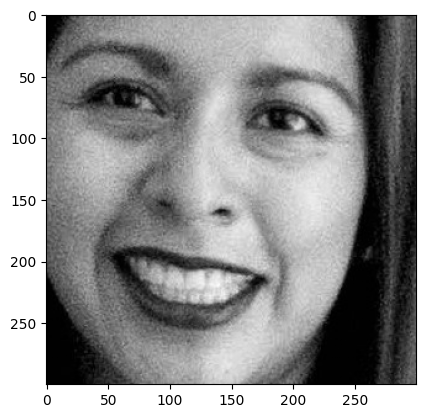

In [4]:
img = cv2.imread(f'{IMG}/face.jpeg')
img = img[200:500, 100:400]
img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_grey, cmap='gray');

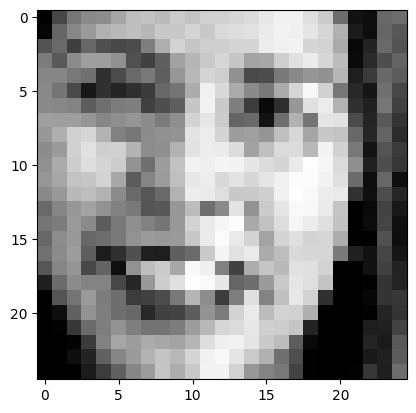

In [5]:
img_grey_small = cv2.resize(img_grey, (25, 25))
plt.imshow(img_grey_small, cmap='gray');

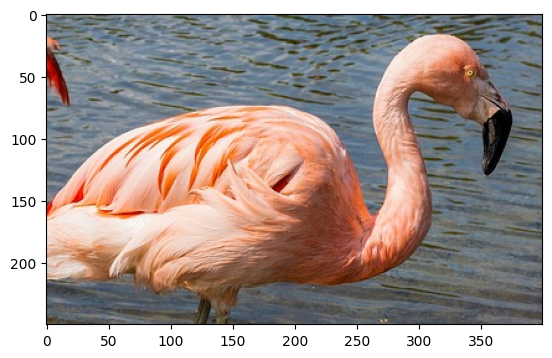

In [6]:
img = cv2.imread(f'{IMG}/flamingos.jpg')
img = img[150:400, 300:700]
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img);

In [7]:
data_folder = f'{IMG}/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

In [8]:
tr_imgs = fmnist.data
tr_targets = fmnist.targets

In [9]:
unique_vals = tr_targets.unique()
print(f'X: {tr_imgs.shape}\nY: {tr_targets.shape}\nY vals: {unique_vals}')
print(f'n classes: {len(unique_vals)}')
print(f'classes: {fmnist.classes}')

X: torch.Size([60000, 28, 28])
Y: torch.Size([60000])
Y vals: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
n classes: 10
classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


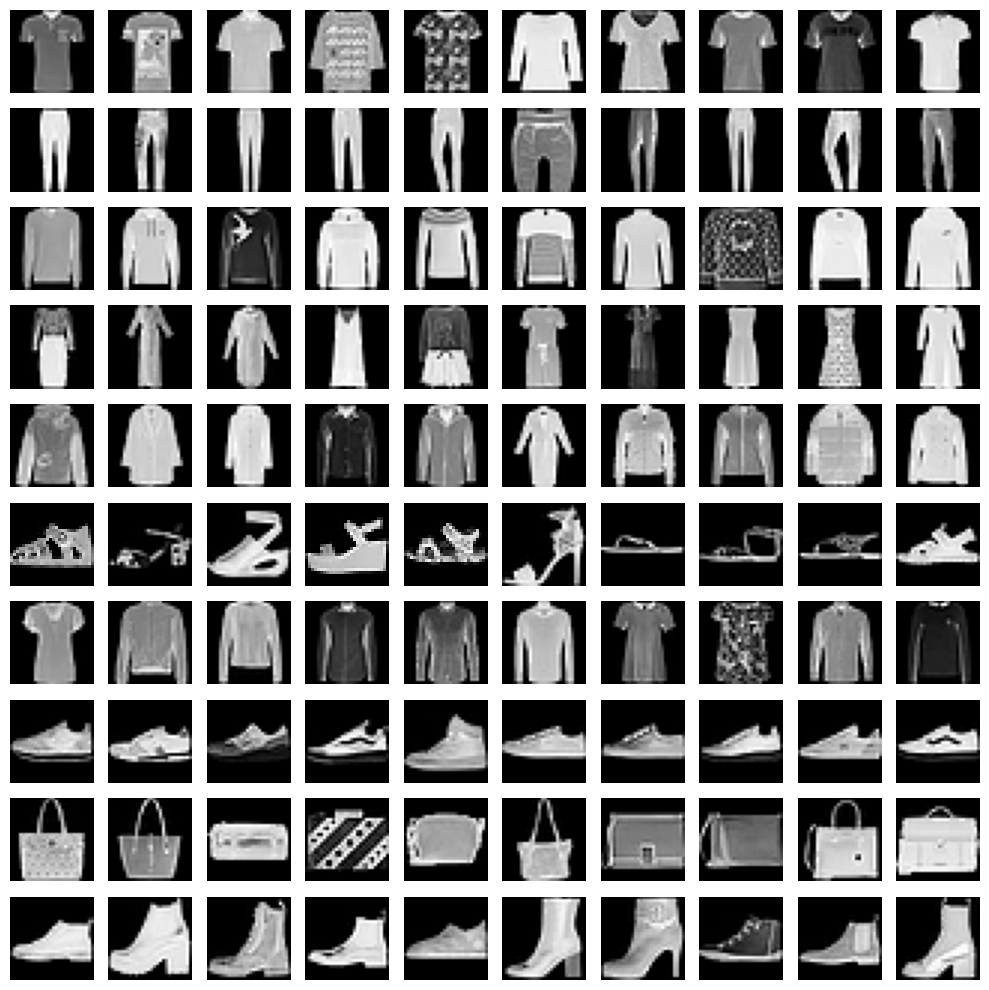

In [10]:
r, c = len(tr_targets.unique()), 10
fig, ax = plt.subplots(r, c, figsize=(10, 10))
for i, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == i)[0]
    for p in plot_row:
        p.grid(False)
        p.axis('off')
        idx = np.random.choice(label_x_rows)
        x, y = tr_imgs[idx], tr_targets[idx]
        p.imshow(x, cmap='gray')
plt.tight_layout();

In [15]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [17]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)
        self.x = x 
        self.y = y

    def __getitem__(self, i):
        x, y = self.x[i], self.y[i]
        return x.to(DEVICE), y.to(DEVICE)

    def __len__(self):
        return len(self.x)

In [18]:
def get_data(batch=32, shuffle=True):
    train = FMNISTDataset(tr_images, tr_targets)
    train_dl = DataLoader(train, batch_size=batch, shuffle=shuffle)
    return train_dl

In [20]:
def get_model(lr=1e-2):
    mod = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(DEVICE)
    loss_f = nn.CrossEntropyLoss()
    optim = SGD(model.parameters(), lr=lr)
    return mod, loss_f, optim